| **ID**| **Name**| 
|-|-|
| 22280075     | Huynh Thao Quynh  | 
| 22280091 | Nguyen Ngoc Thanh Thu  | 

# **Final Project**

## **Problem stament :**     

The widespread dissemination of fake news and propaganda presents serious societal risks, including the erosion of public trust, political polarization, manipulation of elections, and the spread of harmful misinformation during crises such as pandemics or conflicts. From an NLP perspective, detecting fake news is fraught with challenges. Linguistically, fake news often mimics the tone and structure of legitimate journalism, making it difficult to distinguish using surface-level features. The absence of reliable and up-to-date labeled datasets, especially across multiple languages and regions, hampers the effectiveness of supervised learning models. Additionally, the dynamic and adversarial nature of misinformation means that malicious actors constantly evolve their language and strategies to bypass detection systems. Cultural context, sarcasm, satire, and implicit bias further complicate automated analysis. Moreover, NLP models risk amplifying biases present in training data, leading to unfair classifications and potential censorship of legitimate content. These challenges underscore the need for cautious, context-aware approaches, as the failure to address them can inadvertently contribute to misinformation, rather than mitigate it.



Use datasets in link : https://drive.google.com/drive/folders/1mrX3vPKhEzxG96OCPpCeh9F8m_QKCM4z?usp=sharing
to complete requirement.

## **About dataset:**

* **True Articles**:

  * **File**: `MisinfoSuperset_TRUE.csv`
  * **Sources**:

    * Reputable media outlets like **Reuters**, **The New York Times**, **The Washington Post**, etc.

* **Fake/Misinformation/Propaganda Articles**:

  * **File**: `MisinfoSuperset_FAKE.csv`
  * **Sources**:

    * **American right-wing extremist websites** (e.g., Redflag Newsdesk, Breitbart, Truth Broadcast Network)
    * **Public dataset** from:

      * Ahmed, H., Traore, I., & Saad, S. (2017): "Detection of Online Fake News Using N-Gram Analysis and Machine Learning Techniques" *(Springer LNCS 10618)*



## **Requirement**

A team consisting of three members must complete a project that involves applying the methods learned from the beginning of the course up to the present. The team is expected to follow and document the entire machine learning workflow, which includes the following steps:

1. **Data Preprocessing**: Clean and prepare the dataset,etc.

2. **Exploratory Data Analysis (EDA)**: Explore and visualize the data.

3. **Model Building**: Select and build one or more machine learning models suitable for the problem at hand.

4. **Hyperparameter set up**: Set and adjust the model's hyperparameters using appropriate methods to improve performance.

5. **Model Training**: Train the model(s) on the training dataset.

6. **Performance Evaluation**: Evaluate the trained model(s) using appropriate metrics (e.g., accuracy, precision, recall, F1-score, confusion matrix, etc.) and validate their performance on unseen data.

7. **Conclusion**: Summarize the results, discuss the model's strengths and weaknesses, and suggest possible improvements or future work.





# **OUR PIPELINE**

In [25]:
# Reproducibility
import os
import random
import re
import html
import string
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

# Set random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plotting Libraries (EDA trực quan)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer
from bs4 import BeautifulSoup
from textblob import TextBlob

# Sklearn / ML
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    HalvingGridSearchCV,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from joblib import dump, load

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, MaxPooling1D,
    Bidirectional, LSTM, Dropout, Dense
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# PyTorch / Transformers
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertConfig,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# Ignore warnings
warnings.filterwarnings("ignore")

## **01. Load Data and Preprocessing**

In [26]:
fake_data = pd.read_csv('dataset_misinfo/DataSet_Misinfo_FAKE.csv')
real_data = pd.read_csv('dataset_misinfo/DataSet_Misinfo_TRUE.csv')

fake_data = fake_data.drop(columns=['Unnamed: 0'])
real_data = real_data.drop(columns=['Unnamed: 0'])
fake_data['label'] = 0
real_data['label'] = 1

df = pd.concat([real_data, fake_data], axis=0)
df.reset_index(drop=True, inplace=True)
df.sample(7)

,text,label
60915,ZeroHedge.com ALL CONTENT ON 'SGTREPORT.COM' A...,0
43099,As soon as news broke of notorious hatemonger ...,0
59302,"When I was reading the news this morning, I di...",0
29057,"NAIROBI, Kenya — A suicide bomb rocked the ...",1
68003,Email \nIt’s not exactly breaking news that on...,0
1182,A U.S. judge on Tuesday blocked President Dona...,1
58619,"Rusia, China y Arabia Saudita ponen en jaque l...",0


In [27]:
# Thông tin kích thước và cấu trúc
print("Dataset shape:", df.shape)

# Số lượng mỗi nhãn
print(df['label'].value_counts())

# Kiểm tra và xử lý missing values
missing = df.isnull().sum()
print("\nMissing values:\n", missing)

if missing.sum() > 0:
    df = df.dropna().reset_index(drop=True)

def check_html_tags(text):
    html_pattern = r'<[^>]+>'
    return bool(re.search(html_pattern, text))

print(f"\nSố lượng dòng trùng lặp: {df.duplicated().sum()}")
print(f"Số dòng còn chứa thẻ HTML: {df['text'].apply(check_html_tags).sum()}")


Dataset shape: (78617, 2)
label
0    43642
1    34975
Name: count, dtype: int64

Missing values:
 text     29
label     0
dtype: int64

Số lượng dòng trùng lặp: 9984
Số dòng còn chứa thẻ HTML: 202


In [4]:
nltk.download('stopwords')
nltk.download('vader_lexicon')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return sia.polarity_scores(text)['compound']

def get_textblob_sentiment(text):
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

def clean_text_transformer(text):
    """
    Preprocess text for transformer models.

    Removes escape characters, HTML tags, URLs, repeated special characters,
    and normalizes whitespace.
    """
    text = re.sub(r'[\t\r\n]', ' ', text)
    if re.search(r'<[^>]+>', text):
        text = BeautifulSoup(text, "html.parser").get_text()

    text = re.sub(r'(https?://)([^/\s]+)([^\s]*)', r'\2', text)
    text = re.sub(r'[_~+\-]{2,}', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

def clean_text_ML(text):
    """
    Làm sạch cho mô hình ML:
    - lowercase, bỏ HTML, URL, ký tự thừa
    - remove stopword, stemming
    """
    text = str(text).lower()
    if re.search(r'<[^>]+>', text):
        text = BeautifulSoup(text, "html.parser").get_text()
    text = html.unescape(text)                                 # fĩ
    text = re.sub(r'(https?://)([^/\s]+)([^\s]*)', ' ', text)
    text = re.sub(r'[_~+\-]{2,}', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = text.split()
    filtered = [stemmer.stem(w) for w in tokens
                if w.isalnum() and w not in stop_words]       # fĩ
    
    return ' '.join(filtered)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Administra\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [5]:
df = df.drop_duplicates()
df['clean_text_trans'] = df['text'].apply(clean_text_transformer)
df['clean_text_ml'] = df['text'].apply(clean_text_ML)

df['article_length'] = df['clean_text_ml'].apply(lambda x: len(x.split()))
df['sentiment'] = df['clean_text_ml'].apply(get_sentiment)
df['textblob_sentiment'], df['textblob_subjectivity'] = zip(*df['clean_text_ml'].apply(get_textblob_sentiment))
df.head()

,text,label,clean_text_trans,clean_text_ml,article_length,sentiment,textblob_sentiment,textblob_subjectivity
0,The head of a conservative Republican faction ...,1,The head of a conservative Republican faction ...,head conserv republican faction us congress vo...,431,0.9702,0.022500,0.408500
1,Transgender people will be allowed for the fir...,1,Transgender people will be allowed for the fir...,transgend peopl allow first time enlist us mil...,222,0.5719,0.239352,0.518981
2,The special counsel investigation of links bet...,1,The special counsel investigation of links bet...,special counsel investig link russia presid 20...,250,0.5423,0.220640,0.365002
3,Trump campaign adviser George Papadopoulos tol...,1,Trump campaign adviser George Papadopoulos tol...,trump campaign advis georg papadopoulo told au...,218,0.8979,0.104685,0.278385
4,President Donald Trump called on the U.S. Post...,1,President Donald Trump called on the U.S. Post...,presid donald trump call us postal servic frid...,494,0.8979,0.003611,0.365556


In [75]:
index = 500

print("-" * 50)
print(f"TEST OUTPUT (index {index})".center(50))
print("-" * 50)

print(f"\n[1] Origin Text:\n")
print("   *", df['text'][index])

print(f"\n[2] Cleaned Text for ML model:\n")
print("   *", df['clean_text_ml'][index])

print(f"\n[3] Cleaned Text for Transformer model:\n")
print("   *", df['clean_text_trans'][index])

print("-" * 50)


--------------------------------------------------
             TEST OUTPUT (index 500)              
--------------------------------------------------

[1] Origin Text:

   * Popular Tokyo Governor Yuriko Koike, whose fledgling party is gaining momentum ahead of an Oct. 22 general election, said on Thursday at a news conference that she would look into what steps are needed to reduce Japan s dependence on nuclear energy to zero by 2030. Prime Minister Shinzo Abe is calling the snap poll in the hope his Liberal Democratic Party-led coalition can keep its majority in the parliament s lower house, where it now holds two-thirds of the seats. Koike has said she wants Japan to abandon nuclear power

[2] Cleaned Text for ML model:

   * popular tokyo governor yuriko koik whose fledgl parti gain momentum ahead oct 22 gener elect said thursday news confer would look step need reduc japan depend nuclear energi zero 2030 prime minist shinzo abe call snap poll hope liber democrat partyl coalit k

In [53]:
df1 = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Dataset shape:", df1.shape)

Dataset shape: (68604, 8)


In [76]:
# # LƯU VÀ LOAD LẠI DATA 
# df1.to_parquet("dataset_misinfo/data_after_preprocess.parquet", index=False)
df = pd.read_parquet("dataset_misinfo/data_after_preprocess.parquet")

## **02. EDA**

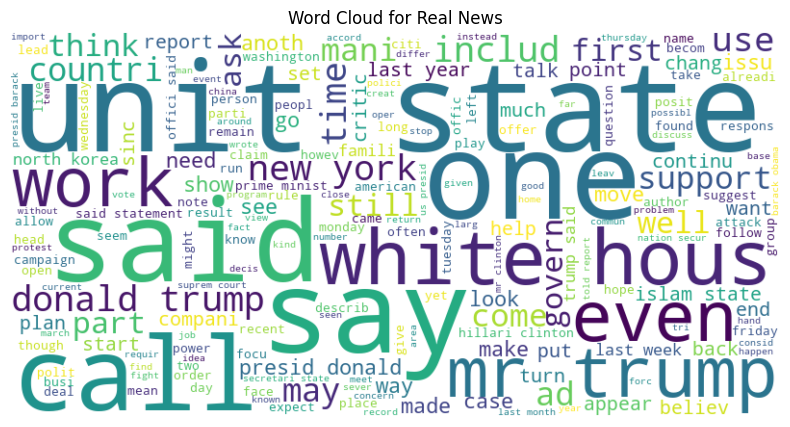

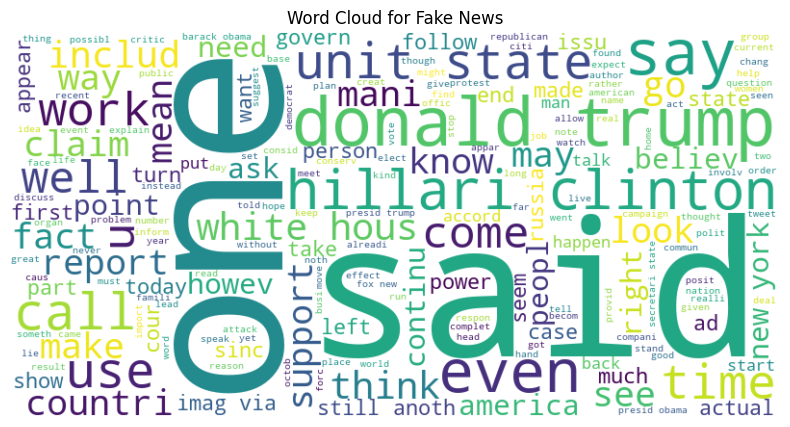

In [12]:
def plot_word_cloud(data, title):
    text_data = ' '.join(data.astype(str))
    if not text_data.strip():  
        print(f"No text data available for {title}")
        return
    
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate word clouds for Real (label=1) and Fake (label=0) news
plot_word_cloud(df[df['label'] == 1]['clean_text_ml'], 'Word Cloud for Real News')
plot_word_cloud(df[df['label'] == 0]['clean_text_ml'], 'Word Cloud for Fake News')

In [14]:
# Count the number of articles by label
article_count = df['label'].value_counts().reset_index()
article_count.columns = ['label', 'count']

# Map labels 0, 1 to Fake, Real
article_count['label'] = article_count['label'].map({0: 'Fake', 1: 'Real'})

print("Number of articles by label:")
print(article_count)

# Create a bar chart 
fig = go.Figure()

fig.add_trace(go.Bar(
    x=article_count['label'],
    y=article_count['count'],
    marker_color=['#FF6B6B', '#4ECDC4'],  
    text=article_count['count'], 
    textposition='outside',
    texttemplate='%{text:.0f}',  
    width=0.3,  
    marker_line=dict(color='#000000', width=1)  
))

fig.update_layout(
    title=dict(
        text='Number of Articles by News Type',
        font=dict(size=20, color='#333333'),
        x=0.5,
        xanchor='center'
    ),
    xaxis_title='News Type',
    yaxis_title='Number of Articles',
    font=dict(family='Arial', size=14, color='#333333'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        showgrid=False,
        title_font=dict(size=16),
        tickfont=dict(size=14)
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgrey',
        gridwidth=1,
        title_font=dict(size=16),
        tickfont=dict(size=14),
        range=[0, max(article_count['count']) * 1.2] 
    ),
    bargap=0.05,  
    showlegend=False,
    margin=dict(l=50, r=50, t=80, b=50),
    height=500
)

fig.show()

Number of articles by label:
  label  count
0  Fake  43642
1  Real  34946


In [15]:
# Calculate the average article length by label
article_length_avg = df.groupby('label')['article_length'].mean().reset_index()
article_length_avg.columns = ['label', 'avg_length']

# Map labels 0, 1 to Fake, Real
article_length_avg['label'] = article_length_avg['label'].map({0: 'Fake', 1: 'Real'})

print("Average article length by label:")
print(article_length_avg)

# Create a bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=article_length_avg['label'],
    y=article_length_avg['avg_length'],
    marker_color=['#FF6B6B', '#4ECDC4'],  
    text=article_length_avg['avg_length'], 
    textposition='outside',
    texttemplate='%{text:.1f}', 
    width=0.3, 
    marker_line=dict(color='#000000', width=1)  
))

fig.update_layout(
    title=dict(
        text='Average Article Length by News Type',
        font=dict(size=20, color='#333333'),
        x=0.5,
        xanchor='center'
    ),
    xaxis_title='News Type',
    yaxis_title='Average Length (words)',
    font=dict(family='Arial', size=14, color='#333333'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        showgrid=False,
        title_font=dict(size=16),
        tickfont=dict(size=14)
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgrey',
        gridwidth=1,
        title_font=dict(size=16),
        tickfont=dict(size=14),
        range=[0, max(article_length_avg['avg_length']) * 1.2]  
    ),
    bargap=0.05,  
    showlegend=False,
    margin=dict(l=50, r=50, t=80, b=50),
    height=500
)

fig.show()

Average article length by label:
  label  avg_length
0  Fake  234.962330
1  Real  290.211469


In [16]:
# Calculate mean, max, and min sentiment scores for each label
mean_sentiment = df.groupby('label')['sentiment'].mean().reset_index()
max_sentiment = df.groupby('label')['sentiment'].max().reset_index()
min_sentiment = df.groupby('label')['sentiment'].min().reset_index()

summary_sentiment = pd.merge(mean_sentiment, max_sentiment, on='label', suffixes=('_mean', '_max'))
summary_sentiment = pd.merge(summary_sentiment, min_sentiment, on='label')
summary_sentiment.rename(columns={'sentiment': 'sentiment_min'}, inplace=True)

for index, row in summary_sentiment.iterrows():
    print(f"Label: {row['label']}, Mean Sentiment: {row['sentiment_mean']:.2f}, Max Sentiment: {row['sentiment_max']:.2f}, Min Sentiment: {row['sentiment_min']:.2f}")

# Create a violin plot for sentiment scores
fig = px.violin(df, 
                 x='label', 
                 y='sentiment', 
                 box=True, 
                 points='all', 
                 title='Sentiment Polarity Distribution by Label',
                 color='label',  # Color by label
                 color_discrete_sequence=['#FF6B6B', '#4ECDC4'])  # Custom colors

fig.update_traces(meanline_visible=True)  
fig.update_layout(yaxis_title='Sentiment Score',
                  xaxis_title='News Category',
                  legend_title='Label',
                  legend=dict(x=0.85, y=0.9))  

fig.show()

Label: 0.0, Mean Sentiment: -0.06, Max Sentiment: 1.00, Min Sentiment: -1.00
Label: 1.0, Mean Sentiment: 0.02, Max Sentiment: 1.00, Min Sentiment: -1.00


In [18]:
# Calculate mean, max, and min sentiment scores for each label
mean_sentiment = df.groupby('label')['textblob_sentiment'].mean().reset_index()
max_sentiment = df.groupby('label')['textblob_sentiment'].max().reset_index()
min_sentiment = df.groupby('label')['textblob_sentiment'].min().reset_index()

summary_sentiment = pd.merge(mean_sentiment, max_sentiment, on='label', suffixes=('_mean', '_max'))
summary_sentiment = pd.merge(summary_sentiment, min_sentiment, on='label')
summary_sentiment.rename(columns={'textblob_sentiment': 'textblob_sentiment_min'}, inplace=True)

for index, row in summary_sentiment.iterrows():
    print(f"Label: {row['label']}, Mean Sentiment: {row['textblob_sentiment_mean']:.2f}, Max Sentiment: {row['textblob_sentiment_max']:.2f}, Min Sentiment: {row['textblob_sentiment_min']:.2f}")

# Create the violin plot
fig = px.violin(df, x='label', y='textblob_sentiment', box=True, points='all',
                 title='TextBlob Sentiment Polarity Distribution by Label',
                 color='label',  
                 color_discrete_sequence=px.colors.qualitative.Set2)

for index, row in summary_sentiment.iterrows():
    # Annotate mean score
    fig.add_annotation(
        x=row['label'],
        y=row['textblob_sentiment_mean'],
        text=f'Mean: {row["textblob_sentiment_mean"]:.2f}',  
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=-40,  
        font=dict(color='black', size=12)
    )

    fig.add_annotation(
        x=row['label'],
        y=row['textblob_sentiment_max'],
        text=f'Max: {row["textblob_sentiment_max"]:.2f}',  
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=-20,
        font=dict(color='red', size=12) 
    )
    # Annotate min score
    fig.add_annotation(
        x=row['label'],
        y=row['textblob_sentiment_min'],
        text=f'Min: {row["textblob_sentiment_min"]:.2f}',  
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=0, 
        font=dict(color='blue', size=12) 
    )

fig.update_layout(
    legend_title_text='Label',
    yaxis_title='TextBlob Sentiment Polarity',
    xaxis_title='Label',
    template='plotly_white'  
)

fig.show()

Label: 0.0, Mean Sentiment: 0.07, Max Sentiment: 1.00, Min Sentiment: -1.00
Label: 1.0, Mean Sentiment: 0.07, Max Sentiment: 1.00, Min Sentiment: -0.88


In [19]:
# Function to get top N words, excluding stopwords
def get_top_n_words(corpus, n=10):
    words = ' '.join(corpus).split()
    words = [word for word in words if word.isalpha() and word.lower() not in stop_words]
    common_words = Counter(words)
    return common_words.most_common(n)

# Function to plot top N words 
def plot_top_n_words(data, title, n=10, base_color='#000000', highlight_color='#000000'):
    top_words = get_top_n_words(data['clean_text_ml'], n)
    if not top_words:  
        print(f"No significant words to plot for {title}")
        return
    
    words, counts = zip(*top_words)
    
    counts = list(counts)
    words = list(words)

    print(f"Top words for {title}:")
    for word, count in zip(words, counts):
        print(f"{word}: {count}")
    
    max_count_index = counts.index(max(counts))

    colors = [highlight_color if i == max_count_index else base_color for i in range(len(counts))]

    fig = px.bar(x=words, y=counts, 
                 title=title, 
                 labels={'x': 'Words', 'y': 'Counts'},
                 color=words,  
                 color_discrete_map={word: color for word, color in zip(words, colors)},
                 text=counts, 
                 text_auto=True)  

    fig.update_traces(textposition='outside')
    
    fig.update_layout(
        title=dict(text=title, 
                   font=dict(size=20, color='#333333'), 
                   x=0.5, 
                   xanchor='center'),
        xaxis_title='Words',
        yaxis_title='Counts',
        font=dict(family='Arial', size=14, color='#333333'),
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(
            showgrid=False, 
            title_font=dict(size=16),
            tickfont=dict(size=14),
            tickangle=45  
        ),
        yaxis=dict(
            showgrid=True, 
            gridcolor='lightgrey', 
            gridwidth=1,
            title_font=dict(size=16),
            tickfont=dict(size=14)
        ),
        showlegend=False,
        margin=dict(l=50, r=50, t=80, b=50),
        height=500
    )
    
    fig.show()

real_base_color = '#4ECDC4'  
real_highlight_color = '#2A7C73' 
fake_base_color = '#FF6B6B'  
fake_highlight_color = '#B53030'

In [20]:
# Plot top 10 words for Real and Fake news 
plot_top_n_words(df[df['label'] == 1], 'Top 10 Words in Real News', n=10, 
                 base_color=real_base_color, highlight_color=real_highlight_color)
plot_top_n_words(df[df['label'] == 0], 'Top 10 Words in Fake News', n=10, 
                 base_color=fake_base_color, highlight_color=fake_highlight_color)

Top words for Top 10 Words in Real News:
said: 167444
trump: 76202
mr: 70411
state: 60951
would: 56369
presid: 47376
us: 46136
year: 40057
one: 39180
new: 38532


Top words for Top 10 Words in Fake News:
trump: 96632
us: 50410
peopl: 47938
said: 46977
state: 45378
one: 44878
would: 43080
clinton: 41386
presid: 40216
like: 38131


In [21]:
# Count the number of real and fake news articles
label_counts = df['label'].value_counts()

label_df = pd.DataFrame({'label': label_counts.index, 'count': label_counts.values})
label_df['label'] = label_df['label'].map({0: 'Fake', 1: 'Real'})  

fig = make_subplots(
    rows=1, 
    cols=2, 
    specs=[[{'type': 'pie'}, {'type': 'bar'}]],
    subplot_titles=("Pie Chart of News Labels", "Bar Plot of News Labels"),
    horizontal_spacing=0.15 
)

# Pie Chart
pie_chart = go.Pie(
    labels=label_df['label'], 
    values=label_df['count'], 
    hole=0.4,
    marker_colors=['#FF6B6B', '#4ECDC4'], 
    textinfo='percent+label',
    hoverinfo='label+percent+value'
)
fig.add_trace(pie_chart, row=1, col=1)

# Bar Plot
bar_plot = go.Bar(
    x=label_df['label'], 
    y=label_df['count'], 
    marker_color=['#FF6B6B', '#4ECDC4'],
    text=label_df['count'],
    textposition='outside'
)
fig.add_trace(bar_plot, row=1, col=2)

fig.update_layout(
    title=dict(
        text='Distribution of Real and Fake News',
        font=dict(size=20, color='#333333'),
        x=0.5,
        xanchor='center'
    ),
    font=dict(family='Arial', size=14, color='#333333'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=True,
    legend=dict(
        title='News Type',
        x=0.85,
        y=0.9
    ),
    height=500,
    width=1000,  
    margin=dict(l=50, r=50, t=80, b=50)
)

fig.update_yaxes(
    title_text='Number of Articles',
    showgrid=True,
    gridcolor='lightgrey',
    gridwidth=1,
    tickformat=',',
    title_font=dict(size=16),
    tickfont=dict(size=14),
    range=[0, max(label_df['count']) * 1.2],
    row=1, col=2
)
fig.update_xaxes(
    title_text='News Type',
    title_font=dict(size=16),
    tickfont=dict(size=14),
    row=1, col=2
)

fig.show()

## **03. Prepare model**

In [54]:
X = df1.drop(columns=['label'])
y = df1['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2, 
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)
print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")

Train: 54,883  |  Val: 6,860  |  Test: 6,861


In [ ]:
def evaluate_model(model_name, y_test, y_pred):
    # Metric
    print(f"--------------- {model_name} Model ---------------")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.5f}")
    print(f"Precision: {precision_score(y_test, y_pred):.5f}")
    print(f"Recall: {recall_score(y_test, y_pred):.5f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.5f}")

    # Classification report
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print('-'*30)
    print(f"Predict results (ground truth vs predicted)")
    df_pred = pd.DataFrame({
        'y_test': y_test,
        'Predicted': y_pred.reshape(-1)
    })
    # Xem ngẫu nhiên 10 sample
    display(df_pred.sample(10))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

def visualize_loss(model_name, train_loss, val_loss):
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title(f'Training vs. Validation Loss - {model_name} Model')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## **04. Machine Learning Model**

In [ ]:
# ---------- Vectorizers ----------
tfidf_word = TfidfVectorizer(stop_words="english", ngram_range=(1,3))
tfidf_char = TfidfVectorizer(analyzer="char", ngram_range=(3,5), min_df=3)

# SVM: word + char + meta (StandardScaler)
tfidf_mix_meta = ColumnTransformer([
    ("word", tfidf_word, "clean_text_ml"),
    ("char", tfidf_char, "clean_text_ml"),
    ("meta", StandardScaler(with_mean=False),
             ["article_length", "sentiment"])
])

In [ ]:
vect_dict = {
    "TFIDF_word"             : tfidf_word,
    "TFIDF_char"             : tfidf_char,
    "TFIDF_mix_meta"         : tfidf_mix_meta,
}

clf_dict = {
    "SVM" : LinearSVC(class_weight="balanced")
}

param_grids = {
    # SVM
    ("TFIDF_word",           "SVM"): {"vect__ngram_range":[(1,1),(1,2)],
                                       "clf__C":[0.5,1,4]},
    ("TFIDF_char",           "SVM"): {"vect__min_df":[2,3],
                                       "clf__C":[0.5,1,4]},
    ("TFIDF_mix_meta",       "SVM"): {"prep__word__ngram_range":[(1,2)],
                                       "clf__C":[0.5,1,4]}
}

results, best_f1, best_pipe, best_key = [], -1, None, None

for v_name, vect in vect_dict.items():
    for c_name, clf in clf_dict.items():
        key = (v_name, c_name)
        if key not in param_grids:
            continue

        print(f"\n* {v_name} + {c_name}")

        is_ct = isinstance(vect, ColumnTransformer)
        pipe  = (Pipeline([("prep", vect), ("clf", clf)])
                 if is_ct
                 else Pipeline([("vect", vect), ("clf", clf)]))

        gs = HalvingGridSearchCV(pipe, param_grids[key],
                                 cv=3, scoring="f1",
                                 n_jobs=-1, factor=2, verbose=0)

        X_train_in = X_train if is_ct else X_train["clean_text_ml"]
        X_val_in   = X_val   if is_ct else X_val["clean_text_ml"]

        gs.fit(X_train_in, y_train)

        f1_val = f1_score(y_val, gs.predict(X_val_in))   

        results.append({"Vectorizer": v_name,
                        "Classifier": c_name,
                        "F1_val":     f1_val,
                        "Best_param": gs.best_params_})

        if f1_val > best_f1:
            best_f1, best_key, best_pipe = f1_val, key, gs.best_estimator_


res_df = pd.DataFrame(results).sort_values("F1_val", ascending=False)
pd.set_option("display.max_colwidth", None)
display(res_df)

print(f"\nBEST on Val: {best_key[0]} + {best_key[1]} | F1={best_f1:.4f}")

In [ ]:
best_pipe.fit(pd.concat([X_train, X_val]),
              pd.concat([y_train,  y_val]))

In [ ]:
y_pred_svm = best_pipe.predict(X_test)
evaluate_model('BiLSTM', y_test, y_pred_svm)

## **05. Deep Learning**

In [20]:
X_train_dl = X_train['clean_text_ml']
X_test_dl = X_test['clean_text_ml']
X_val_dl = X_test['clean_text_ml']

In [ ]:
# Phân tích từ hiếm
threshold = 5
tmp_tokenizer = Tokenizer()
tmp_tokenizer.fit_on_texts(X_train_dl)

total_words = len(tmp_tokenizer.word_counts)
rare_words = sum(1 for count in tmp_tokenizer.word_counts.values() if count < threshold)
rare_freq = sum(count for count in tmp_tokenizer.word_counts.values() if count < threshold)
total_freq = sum(tmp_tokenizer.word_counts.values())

print(f"% of rare words in vocabulary: {rare_words / total_words * 100:.2f}%")
print(f"Total coverage of rare words: {rare_freq / total_freq * 100:.2f}%")

In [ ]:
MAX_LEN = 300
embedding_dim = 256
latent_dim = 384

# Tokenizer 
vocab_size = total_words - rare_words
tokenizer_dl = Tokenizer(num_words=vocab_size)
tokenizer_dl.fit_on_texts(X_train)

# Sequence & padding
X_train_seq = tokenizer_dl.texts_to_sequences(X_train_dl)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test_dl)
X_val_seq = tokenizer_dl.texts_to_sequences(X_val_dl)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')
X_val_pad = pad_sequences(X_val_dl, maxlen=MAX_LEN, padding='post')

In [ ]:
epochs=20
batch_size=128
early_stopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1)

def init_model(model_name, dropout=0.1, filters=64, kernel_size=5):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size + 1, output_dim=embedding_dim, input_shape=(MAX_LEN,), trainable=True))
    model.add(Dropout(dropout))

    if model_name == 'lstm':
        model.add(LSTM(latent_dim, return_sequences=False))

    if model_name == 'bilstm':
        model.add(Bidirectional(LSTM(latent_dim, return_sequences=False)))
    
    elif model_name == 'cnn_bilstm':
        # CNN layer
        model.add(Conv1D(filters, kernel_size, activation='relu', strides=1, padding='same'))
        model.add(MaxPooling1D())

        model.add(Conv1D(filters, kernel_size, activation='relu',  strides=1, padding='same'))
        model.add(MaxPooling1D())

        # BiLSTM layer
        model.add(Bidirectional(LSTM(latent_dim, return_sequences=False)))

    else:
        raise ValueError("Unknown model_name. Choose from: 'lstm', 'bilstm', 'cnn_bilstm'")
    
    model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.summary()
    return model


### **5.1. LSTM**

In [ ]:
model_lstm = init_model('lstm')

In [ ]:
# Training
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stopping]
)

In [ ]:
visualize_loss('LSTM', history_lstm.history['loss'], history_lstm.history['val_loss'])

In [ ]:
# Dự đoán
y_prob_lstm = model_lstm.predict(X_test_pad)
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

evaluate_model('LSTM', y_test, y_pred_lstm)

### **5.2. BiLSTM**

In [ ]:
model_bilstm = init_model('bilstm')

In [ ]:
# Training
history_bilstm = model_bilstm.fit(
    X_train_pad, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stopping]
)

In [ ]:
visualize_loss('BiLSTM', history_bilstm.history['loss'], history_bilstm.history['val_loss'])

In [ ]:
# Dự đoán
y_prob_bilstm = model_bilstm.predict(X_test_pad)
y_pred_bilstm = (y_prob_bilstm >= 0.5).astype(int)

evaluate_model('BiLSTM', y_test, y_pred_bilstm)

### **5.3. CNN - BiLSTM**

In [ ]:
model_combine = init_model('cnn_bilstm')

In [ ]:
# Training
combine_history = model_combine.fit(
    X_train_pad, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stopping]
)

In [ ]:
# Dự đoán
y_prob_combine = model_combine.predict(X_test_pad)
y_pred_combine = (y_prob_combine >= 0.5).astype(int)

evaluate_model('BiLSTM', y_test, y_pred_combine)

## **06. Transformer**

In [ ]:
# ------------ 1. Tokenizer ------------
def tokenize_data(texts, model_name='bert-base-uncased', max_length=256):
    tokenizer = BertTokenizer.from_pretrained(model_name)

    encoding = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length
    )
    return encoding

In [ ]:
# ------------ 2. Dataset ------------
class FakeNewDataset(Dataset):
    def __init__(self, encodings, labels=None):
        super().__init__()
        self.encodings = encodings
        self.labels = labels 
    
    def __len__(self):
        return len(self.encodings['input_ids'])
    
    def __getitem__(self, index):
        item = {key: torch.tensor(val[index]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[index])
        return item

In [ ]:
# ------------ 3. Model ------------
def get_model(model_name='bert-base-uncased', num_labels=2):
    config = BertConfig.from_pretrained('bert-base-uncased', num_labels=num_labels, hidden_dropout_prob=0.5, attention_probs_dropout_prob=0.5)
    model = BertForSequenceClassification.from_pretrained(
        model_name,
        config=config
    )
    return model

In [ ]:
learning_rate = 2e-5
n_epoch = 5
patience = 2
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Trainer:
    def __init__(self, model, train_loader, val_loader, lr, epochs, patience, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.epochs = epochs
        self.device = device
        self.patience = patience
        self.optimizer = AdamW(self.model.parameters(), lr=lr)
        self.model.to(self.device)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        loop = tqdm(self.train_loader, desc="\tTraining", leave=False)
        for batch in loop:
            batch = {k: v.to(self.device) for k, v in batch.items()}
            outputs = self.model(**batch)
            loss = outputs.loss
            loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(self.train_loader)
        return avg_loss

    def evaluate(self):
        self.model.eval()
        all_preds = []
        all_labels = []
        total_loss = 0.0

        loop = tqdm(self.val_loader, desc="\tEvaluating", leave=False)
        with torch.no_grad():
            for batch in loop:
                batch = {k: v.to(self.device) for k, v in batch.items()}
                outputs = self.model(**batch)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch['labels'].cpu().numpy())
                loss = outputs.loss
                total_loss += loss.item()
                loop.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(self.val_loader)
        acc = accuracy_score(all_labels, all_preds)
        return acc, avg_loss

    def train(self):
        best_loss = float('inf')
        patience_counter = 0.0
        for epoch in range(1, self.epochs+1):
            print(f"Epoch {epoch}/{self.epochs}")
            train_loss = self.train_epoch()
            val_acc, val_loss = self.evaluate()

            print(f"\tTrain loss = {train_loss:.5f} | val_loss = {val_loss:.5f}")
            print(f"\tVal accuracy: {val_acc}")

            if val_loss < best_loss:
                best_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print("Early stopping triggered.")
                    break

    def inference_model(self, dataloader):
        self.model.eval()
        all_preds = []

        with torch.no_grad():
            for batch in tqdm(dataloader, desc="Inferencing"):
                batch = {k: v.to(self.device) for k, v in batch.items() if k != 'labels'}
                outputs = self.model(**batch)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())

        return all_preds

In [ ]:
# -------- 5. Prepare data --------
X_train_trans = X_train['clean_text_trans'].tolist()
X_test_trans = X_test['clean_text_trans'].tolist()
X_val_trans = X_val['clean_text_trans'].tolist()

y_train_trans = y_train.tolist()
y_test_trans = y_test.tolist()
y_val_trans = y_val.tolist()

train_encodings = tokenize_data(X_train)
val_encodings = tokenize_data(X_val)
test_encodings = tokenize_data(X_test)

train_dataset = FakeNewDataset(train_encodings, y_train)
val_dataset = FakeNewDataset(val_encodings, y_val)
test_dataset = FakeNewDataset(test_encodings)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
model_bert = get_model()

print(f"-"*50)
print(f"\tTRAINING MODEL: BERT")
print(f"-"*50)
trainer = Trainer(
    model_bert, 
    train_loader, 
    val_loader, 
    lr=learning_rate,
    epochs=n_epoch, 
    patience=patience, 
    device=device
)
trainer.train()

In [ ]:
# Inference
print(f"-"*50)
print(f"\tINFERENCE MODEL")
print(f"-"*50)

y_pred_bert = trainer.inference_model(test_loader)
print(classification_report(y_test, y_pred_bert))